# Chapter 5 — Multiple Opinions, Polarization, and Extremism
**Modeling Social Behavior** | Smaldino

---

### What this notebook does

This is the most structurally different model in Chapter 5. Every previous model gave
each agent **one** opinion. Here each agent holds a **vector** of $K$ opinions
simultaneously, and social influence is determined by **overall similarity** across
all $K$ dimensions at once.

### The key ideas

**Opinion vector:** Agent $i$ is defined by $\vec{x}_i = (x_{i1}, x_{i2}, \ldots, x_{iK})$,
where each $x_{ik} \in [-1, 1]$ (Equation 5.4).

**Distance:** The mean absolute difference across all opinions (Equation 5.5):
$$D_{ij} = \frac{1}{K} \sum_{k=1}^{K} |x_{jk} - x_{ik}| \qquad D_{ij} \in [0, 2]$$

**Influence weight:** A single number that encodes both direction and strength
(Equation 5.6):
$$w_{ij} = 1 - D_{ij} \qquad w_{ij} \in [-1, 1]$$

- $w_{ij} > 0$: agents are similar overall → positive influence (converge)
- $w_{ij} < 0$: agents are dissimilar overall → negative influence (diverge)
- $w_{ij} = 0$: agents are at the exact midpoint of similarity → no influence

**Update rule** (Equation 5.7) — applied independently to each opinion $k$:
$$x_{ik} \leftarrow x_{ik} + \frac{1}{2}\, w_{ij}(x_{jk} - x_{ik})(1 - |x_{ik}|)$$

### Important structural difference from all previous models

In the original source code, `ask turtles` is used instead of `ask one-of turtles`.
This means **every agent** initiates one interaction per tick — not just one randomly
selected pair. This makes the model update more like a synchronous sweep, and is
why the book's batch experiment runs for only 200 ticks (nonspatial) and 1,000 ticks
(spatial) rather than the tens of thousands needed in previous models.

### Batch experiments (matching the book's XML exactly)

| Experiment | K range | Reps | Ticks | Spatial |
|---|---|---|---|---|
| nonspatial | 1–6 | 30 | 200 | False |
| spatial | 1–10 | 20 | 1,000 | True |


---
## 1. Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm

np.random.seed(42)


---
## 2. Global Parameters

The most important new global parameter is `K` (called `num-opinions` in the original).
It controls the dimensionality of opinion space.

Notice there is **no `confidence_threshold`** and **no `repulsion` toggle** in this
model. The influence direction is entirely determined by the continuous weight $w_{ij}$,
which is always computed and always applied. The threshold-based gating of earlier
models is replaced by a smooth, distance-driven mechanism.

There is also **no `learning_rate`** ($\gamma$). The step size is governed entirely
by $w_{ij}$ (overall similarity) and $(1 - |x_{ik}|)$ (distance to the nearest extreme).


In [2]:
# ── GLOBAL PARAMETERS ──────────────────────────────────────────────────────

L                    = 21     # grid side length; N = L*L = 441 agents
N                    = L * L
K                    = 4      # number of opinions per agent (num-opinions)
n_ticks              = 1_000  # ticks for a single demo run
record_every         = 50     # snapshot frequency for time-series plots

# Toggle — set to True for spatial (neighbors only), False for well-mixed
spatial_interactions = False

print(f"Grid: {L}x{L},  N = {N} agents")
print(f"K = {K} opinions per agent")
print(f"Opinion space: {K}-dimensional hypercube in [-1, 1]^{K}")
print(f"Spatial interactions: {spatial_interactions}")


Grid: 21x21,  N = 441 agents
K = 4 opinions per agent
Opinion space: 4-dimensional hypercube in [-1, 1]^4
Spatial interactions: False


---
## 3. Initialization

### Agent variable: `opinions` — shape (N, K)

The key structural change from previous notebooks: `opinions` is now a 2D array.

- **Row** $i$ = agent $i$'s opinion vector $(x_{i1}, x_{i2}, \ldots, x_{iK})$
- **Column** $k$ = all agents' opinions on issue $k$

Each value is drawn independently from Uniform$[-1, 1]$.

Geometrically: with $K = 1$, agents are points on a line. With $K = 2$, they are
points in a square. With $K = 4$, they are points in a 4-dimensional hypercube.
Agents holding only extreme opinions ($\pm 1$ on every issue) would sit at the
**corners** of this hypercube — hence the book's use of "corners" when discussing
extremism with multiple opinions.

### Global structure: `neighbor_map`
Same toroidal von Neumann 4-neighbor map as before.


In [3]:
def build_neighbor_map(L):
    """
    Precompute the 4 von Neumann neighbors for every agent on an L×L toroidal grid.
    Returns a dict: {agent_index: [up, down, left, right]}.
    """
    neighbors = {}
    for i in range(L * L):
        r, c = divmod(i, L)                   # local: row and column of agent i
        neighbors[i] = [
            ((r - 1) % L) * L + c,            # up (wraps at top)
            ((r + 1) % L) * L + c,            # down (wraps at bottom)
            r * L + (c - 1) % L,              # left (wraps at left edge)
            r * L + (c + 1) % L               # right (wraps at right edge)
        ]
    return neighbors


def initialize(L, K, seed=None):
    """
    Initialize the multi-opinion model.

    Parameters
    ----------
    L    : int   Grid side length (global parameter)
    K    : int   Number of opinions per agent (global parameter)
    seed : int   RNG seed

    Returns
    -------
    opinions     : np.ndarray shape (N, K)  — agent variable: opinion vectors
    neighbor_map : dict                     — global structure: precomputed neighbors
    """
    rng      = np.random.default_rng(seed)
    N        = L * L
    # Agent variable: each row is one agent's K-dimensional opinion vector
    # Each value drawn independently from Uniform[-1, 1]
    opinions = rng.uniform(-1.0, 1.0, size=(N, K))
    return opinions, build_neighbor_map(L)


# ── RUN INITIALIZATION ──────────────────────────────────────────────────────

opinions, neighbor_map = initialize(L, K, seed=42)

print(f"opinions array shape: {opinions.shape}  → ({N} agents, {K} opinions each)")
print(f"Agent 0 opinion vector: {opinions[0].round(4)}")
print(f"Agent 1 opinion vector: {opinions[1].round(4)}")
print(f"Per-opinion means: {opinions.mean(axis=0).round(4)}  (all expected ≈ 0)")
print(f"Per-opinion stds:  {opinions.std(axis=0).round(4)}   (all expected ≈ 0.577)")


opinions array shape: (441, 4)  → (441 agents, 4 opinions each)
Agent 0 opinion vector: [ 0.5479 -0.1222  0.7172  0.3947]
Agent 1 opinion vector: [-0.8116  0.9512  0.5223  0.5721]
Per-opinion means: [-0.0278  0.0376  0.0231 -0.0124]  (all expected ≈ 0)
Per-opinion stds:  [0.5882 0.5668 0.6018 0.5675]   (all expected ≈ 0.577)


---
## 4. Distance and Influence Weight

### Opinion distance — Equation 5.5

$$D_{ij} = \frac{1}{K} \sum_{k=1}^{K} |x_{jk} - x_{ik}|}$$

This is the **Manhattan distance**, normalized by $K$ so it always falls in $[0, 2]$
regardless of how many opinions there are.

- $D_{ij} = 0$: agents agree on every single issue
- $D_{ij} = 2$: agents are at opposite extremes ($\pm 1$) on every single issue

### Influence weight — Equation 5.6

$$w_{ij} = 1 - D_{ij}$$

| $D_{ij}$ | $w_{ij}$ | Effect |
|---|---|---|
| 0 | +1 | Maximum attraction — opinions converge strongly |
| 1 | 0 | No influence — agents are "orthogonal" in opinion space |
| 2 | −1 | Maximum repulsion — opinions diverge strongly |

Notice: $w_{ij}$ is the same for both agents in a pair. This is because
distance is symmetric ($D_{ij} = D_{ji}$), so influence strength is the same
in both directions — only the direction of movement on each opinion axis differs.


In [4]:
def opinion_distance(vec_i, vec_j):
    """
    Compute the normalized Manhattan distance between two opinion vectors.
    Equation 5.5: D_ij = (1/K) * sum_k |x_jk - x_ik|

    Parameters
    ----------
    vec_i, vec_j : np.ndarray shape (K,)  — opinion vectors of agents i and j (local)

    Returns
    -------
    float in [0, 2]
    """
    return np.mean(np.abs(vec_j - vec_i))   # mean absolute difference across K opinions


def influence_weight(vec_i, vec_j):
    """
    Compute the influence weight between two agents.
    Equation 5.6: w_ij = 1 - D_ij

    Returns
    -------
    float in [-1, 1]: positive = converge, zero = no effect, negative = diverge
    """
    return 1.0 - opinion_distance(vec_i, vec_j)


# ── SANITY CHECKS ────────────────────────────────────────────────────────────

# Case 1: identical agents — maximum attraction
a = np.array([0.3, -0.5, 0.7, 0.1])
b = np.array([0.3, -0.5, 0.7, 0.1])
print(f"Identical agents:      D = {opinion_distance(a,b):.4f},  w = {influence_weight(a,b):.4f}  (expected D=0, w=+1)")

# Case 2: opposite extremes — maximum repulsion
a2 = np.array([ 1.0,  1.0,  1.0,  1.0])
b2 = np.array([-1.0, -1.0, -1.0, -1.0])
print(f"Opposite extremes:     D = {opinion_distance(a2,b2):.4f},  w = {influence_weight(a2,b2):.4f}  (expected D=2, w=-1)")

# Case 3: moderate difference — somewhere in between
a3 = np.array([0.5, -0.3,  0.2,  0.8])
b3 = np.array([-0.2, 0.4, -0.5, -0.1])
d3 = opinion_distance(a3, b3)
print(f"Moderate difference:   D = {d3:.4f},  w = {influence_weight(a3,b3):.4f}")
print(f"  (D in [0,2]: {0 <= d3 <= 2},  w in [-1,1]: {-1 <= influence_weight(a3,b3) <= 1})")

# Verify symmetry: D_ij = D_ji
print(f"Symmetry check:        D(a3,b3)={opinion_distance(a3,b3):.6f}  ==  D(b3,a3)={opinion_distance(b3,a3):.6f}  ✓")


Identical agents:      D = 0.0000,  w = 1.0000  (expected D=0, w=+1)
Opposite extremes:     D = 2.0000,  w = -1.0000  (expected D=2, w=-1)
Moderate difference:   D = 0.7500,  w = 0.2500
  (D in [0,2]: True,  w in [-1,1]: True)
Symmetry check:        D(a3,b3)=0.750000  ==  D(b3,a3)=0.750000  ✓


---
## 5. The Update Rule — Equation 5.7

For each opinion $k$, both agents update simultaneously:

$$x_{ik} \leftarrow x_{ik} + \frac{1}{2}\, w_{ij}(x_{jk} - x_{ik})(1 - |x_{ik}|)$$
$$x_{jk} \leftarrow x_{jk} + \frac{1}{2}\, w_{ij}(x_{ik} - x_{jk})(1 - |x_{jk}|)$$

### Dissecting the three multiplicative terms

**$w_{ij}$** — the influence weight (computed once per interaction, applied to all $K$ opinions).
When positive: agents converge on this opinion. When negative: they diverge.

**$(x_{jk} - x_{ik})$** — the gap on this specific opinion. Larger gaps → larger
updates. When $w_{ij} < 0$, the sign flips: $(x_{jk} - x_{ik})$ would normally pull
$x_{ik}$ toward $x_{jk}$, but the negative $w_{ij}$ reverses it, pushing $x_{ik}$ away.

**$(1 - |x_{ik}|)$** — the boundary brake. The distance from $x_{ik}$ to the nearest
extreme ($\pm 1$). Shrinks to 0 as $x_{ik}$ approaches $\pm 1$, preventing overshoot.
This term is present for **all** interactions — positive and negative alike — unlike
Equation 5.3 where it only appeared for negative influence.

**$\frac{1}{2}$** — scales the step; divides by 2 because the maximum opinion range is 2.

### No learning rate $\gamma$

This model has no free $\gamma$ parameter. The interaction strength is fully determined
by $w_{ij}$ and the boundary brake. The implicit assumption is that more extreme agents
(those already near $\pm 1$) shift less than moderate agents — they are harder to move.


In [5]:
def multi_opinion_update(opinions, i, j):
    """
    Apply Equation 5.7: update all K opinions for agents i and j.

    The influence weight w_ij is computed once from the full opinion vectors,
    then applied independently to each of the K opinions.
    Modifies opinions array in place.

    Parameters
    ----------
    opinions : np.ndarray shape (N, K)  — agent variable, modified in place
    i, j     : int                      — indices of the two interacting agents (local)
    """
    vec_i = opinions[i].copy()   # local: copy so updates to i don't affect j's calculation
    vec_j = opinions[j].copy()   # local: copy partner's current opinions

    # Step 1: compute influence weight from overall opinion distance (Eq. 5.6)
    w = influence_weight(vec_i, vec_j)    # local: scalar in [-1, 1]

    # Step 2: update each opinion independently using Equation 5.7
    for k in range(len(vec_i)):
        x_ik = vec_i[k]    # local: agent i's current opinion on issue k
        x_jk = vec_j[k]    # local: agent j's current opinion on issue k

        # x_ik moves toward x_jk when w > 0 (similar agents)
        # x_ik moves away from x_jk when w < 0 (dissimilar agents)
        # (1 - abs(x_ik)) prevents opinions from exceeding ±1
        opinions[i, k] = x_ik + 0.5 * w * (x_jk - x_ik) * (1 - abs(x_ik))
        opinions[j, k] = x_jk + 0.5 * w * (x_ik - x_jk) * (1 - abs(x_jk))


# ── SANITY CHECKS ────────────────────────────────────────────────────────────

print("=== Similar agents (w > 0): should converge on each opinion ===")
ops_test = np.array([[0.2, -0.1, 0.3, 0.4],
                     [0.3,  0.1, 0.5, 0.2]], dtype=float)
w_before = influence_weight(ops_test[0], ops_test[1])
print(f"  w = {w_before:.4f}  (positive → will converge)")
before = ops_test.copy()
multi_opinion_update(ops_test, 0, 1)
for k in range(4):
    moved_closer = abs(ops_test[0,k] - ops_test[1,k]) < abs(before[0,k] - before[1,k])
    print(f"  Opinion {k}: gap {abs(before[0,k]-before[1,k]):.3f} → {abs(ops_test[0,k]-ops_test[1,k]):.3f}  closer: {moved_closer}")

print()
print("=== Dissimilar agents (w < 0): should diverge on each opinion ===")
ops_test2 = np.array([[ 0.8,  0.7,  0.6,  0.9],
                      [-0.8, -0.6, -0.7, -0.5]], dtype=float)
w_before2 = influence_weight(ops_test2[0], ops_test2[1])
print(f"  w = {w_before2:.4f}  (negative → will diverge)")
before2 = ops_test2.copy()
multi_opinion_update(ops_test2, 0, 1)
all_in_bounds = np.all(np.abs(ops_test2) <= 1.0)
print(f"  All opinions still in [-1, 1]: {all_in_bounds}  ✓")
for k in range(4):
    moved_apart = abs(ops_test2[0,k] - ops_test2[1,k]) > abs(before2[0,k] - before2[1,k])
    print(f"  Opinion {k}: gap {abs(before2[0,k]-before2[1,k]):.3f} → {abs(ops_test2[0,k]-ops_test2[1,k]):.3f}  further apart: {moved_apart}")


=== Similar agents (w > 0): should converge on each opinion ===
  w = 0.8250  (positive → will converge)
  Opinion 0: gap 0.100 → 0.038  closer: True
  Opinion 1: gap 0.200 → 0.051  closer: True
  Opinion 2: gap 0.200 → 0.101  closer: True
  Opinion 3: gap 0.200 → 0.085  closer: True

=== Dissimilar agents (w < 0): should diverge on each opinion ===
  w = -0.4000  (negative → will diverge)
  All opinions still in [-1, 1]: True  ✓
  Opinion 0: gap 1.600 → 1.728  further apart: True
  Opinion 1: gap 1.300 → 1.482  further apart: True
  Opinion 2: gap 1.300 → 1.482  further apart: True
  Opinion 3: gap 1.400 → 1.568  further apart: True


---
## 6. The Simulation Loop

### Critical difference from all previous models

The original code uses `ask turtles` — meaning **every agent** initiates one
interaction per tick. In our Python translation this means we loop over all $N$
agents (in a random order) each tick, rather than picking just one pair.

This makes each tick far more computationally expensive than previous models
($N$ interactions vs. 1), which is why the batch experiments use only 200 and
1,000 ticks rather than tens of thousands.

We track **both** metrics at every tick:
- `polarization` = variance of all pairwise distances $D_{ij}$
- `extremism` = proportion of all opinions with $|x_{ik}| > 0.9$


In [6]:
def compute_polarization(opinions):
    """
    Polarization = variance of all pairwise opinion distances D_ij.
    Equation 5.8: P = var(D_ij)

    We compute distances only for pairs (i, j) with i < j to avoid double-counting.

    Parameters
    ----------
    opinions : np.ndarray shape (N, K)  — agent variable

    Returns
    -------
    float: variance of pairwise distances (0 = consensus or uniform; high = polarized)
    """
    N = len(opinions)
    distances = []                        # local: collector for all pairwise distances
    for i in range(N):
        for j in range(i + 1, N):        # only i < j pairs to avoid double-counting
            distances.append(opinion_distance(opinions[i], opinions[j]))
    return float(np.var(distances))


def compute_extremism(opinions):
    """
    Extremism = proportion of all individual opinions with |x_ik| > 0.9.

    Parameters
    ----------
    opinions : np.ndarray shape (N, K)  — agent variable

    Returns
    -------
    float in [0, 1]: 0 = no extreme opinions; 1 = all opinions at extremes
    """
    return float(np.mean(np.abs(opinions) > 0.9))


def run_simulation(opinions, neighbor_map, K, n_ticks,
                   record_every, spatial_interactions, seed=None):
    """
    Run the multi-opinion model for n_ticks steps.

    Each tick: every agent (in random order) initiates one interaction.
    This matches the original 'ask turtles' behaviour.

    Parameters  (all global parameters passed in explicitly)
    ----------
    opinions             : np.ndarray shape (N, K)  — agent variable, modified in place
    neighbor_map         : dict                     — global structure
    K                    : int                      — opinions per agent
    n_ticks              : int                      — number of ticks
    record_every         : int                      — snapshot frequency
    spatial_interactions : bool                     — well-mixed vs. spatial

    Returns
    -------
    opinion1_history : list of (tick, op1_values)  — first opinion snapshots for grid viz
    pol_over_time    : list of float               — polarization per tick
    ext_over_time    : list of float               — extremism per tick
    scatter_history  : list of (tick, op1, op2)    — for 2D opinion scatterplot
    """
    N   = len(opinions)
    rng = np.random.default_rng(seed)

    pol_over_time    = []    # local: polarization at each tick
    ext_over_time    = []    # local: extremism at each tick
    scatter_history  = []    # local: (tick, opinion1_value, opinion2_value) per agent per snapshot

    for tick in range(n_ticks + 1):

        # ── RECORD METRICS AND SNAPSHOTS ──────────────────────────────────
        pol_over_time.append(compute_polarization(opinions))
        ext_over_time.append(compute_extremism(opinions))

        if tick % record_every == 0:
            for idx in range(N):
                op2_val = opinions[idx, 1] if K >= 2 else 0.0   # local
                scatter_history.append((tick, opinions[idx, 0], op2_val))

        if tick == n_ticks:
            break

        # ── ALL AGENTS INTERACT (matching 'ask turtles' in original) ──────
        # Shuffle order each tick so no agent is systematically first
        agent_order = rng.permutation(N)    # local: random ordering this tick

        for i in agent_order:
            # Choose interaction partner
            if spatial_interactions:
                j = int(rng.choice(neighbor_map[i]))          # local: spatial neighbor
            else:
                other = np.delete(np.arange(N), i)            # local: everyone else
                j = int(rng.choice(other))                    # local: random partner

            # Apply Equation 5.7 to all K opinions
            multi_opinion_update(opinions, i, j)

    return pol_over_time, ext_over_time, scatter_history


# ── QUICK TEST RUN ───────────────────────────────────────────────────────────

opinions, neighbor_map = initialize(L, K, seed=42)
print(f"Running multi-opinion model  (K={K}, N={N}, {n_ticks} ticks)...")

pol_traj, ext_traj, scatter_hist = run_simulation(
    opinions, neighbor_map, K,
    n_ticks=n_ticks, record_every=record_every,
    spatial_interactions=spatial_interactions,
    seed=42
)

print(f"Complete.")
print(f"  Initial polarization : {pol_traj[0]:.4f}")
print(f"  Final polarization   : {pol_traj[-1]:.4f}")
print(f"  Initial extremism    : {ext_traj[0]:.4f}")
print(f"  Final extremism      : {ext_traj[-1]:.4f}")
print(f"  Opinion 1 final range: [{opinions[:,0].min():.3f}, {opinions[:,0].max():.3f}]")


Running multi-opinion model  (K=4, N=441, 1000 ticks)...
Complete.
  Initial polarization : 0.0571
  Final polarization   : 0.0126
  Initial extremism    : 0.0981
  Final extremism      : 0.0023
  Opinion 1 final range: [-0.827, 1.000]


---
## 7. Single-Run Visualizations

Three displays, matching the book's model interface:

**Spatial grid (top-left):** Color encodes opinion 1 (first element of each agent's
vector). Shows whether geographic opinion zones form.

**2D opinion scatterplot (top-right):** Each dot is one agent, plotted at
(opinion 1, opinion 2). This is the key new visualization for this model. It shows
the structure of the population in opinion space — at initialization, agents fill the
full square $[-1,1]^2$ uniformly; as the model runs, they cluster toward corners
(extremism) or other configurations depending on $K$.

**Polarization and extremism over time (bottom):** Both metrics on the same axes,
matching the book's dual-line plot.


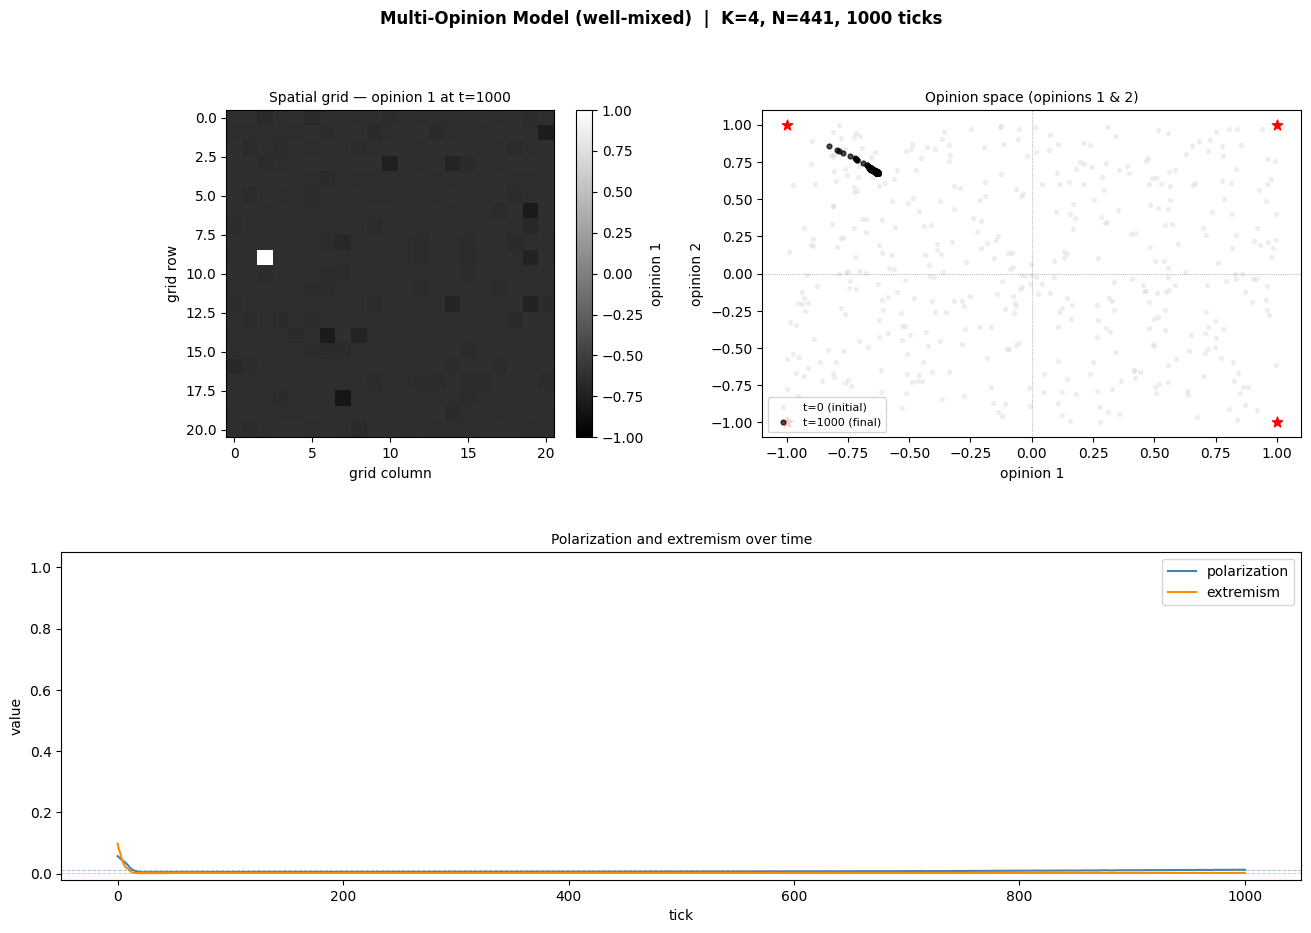

Final polarization: 0.0126
Final extremism:    0.0023


In [7]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

mode = "spatial" if spatial_interactions else "well-mixed"
fig.suptitle(
    f"Multi-Opinion Model ({mode})  |  K={K}, N={N}, {n_ticks} ticks",
    fontsize=12, fontweight='bold'
)

# ── PANEL 1: SPATIAL GRID (opinion 1 only) ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

grid = opinions[:, 0].reshape(L, L)    # local: reshape first opinion to 2D grid
im = ax1.imshow(grid, cmap='gray', vmin=-1, vmax=1,
                interpolation='nearest', aspect='equal')
ax1.set_title(f"Spatial grid — opinion 1 at t={n_ticks}", fontsize=10)
ax1.set_xlabel("grid column")
ax1.set_ylabel("grid row")
plt.colorbar(im, ax=ax1, label='opinion 1', fraction=0.046, pad=0.04)

# ── PANEL 2: 2D OPINION SCATTERPLOT ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

# Snapshot at t=0 (initial) and t=n_ticks (final) for comparison
t0_pts  = [(h[1], h[2]) for h in scatter_hist if h[0] == 0]          # local
tf_pts  = [(h[1], h[2]) for h in scatter_hist if h[0] == n_ticks]    # local

ax2.scatter([p[0] for p in t0_pts], [p[1] for p in t0_pts],
            s=8, alpha=0.3, color='lightgray', label='t=0 (initial)')
ax2.scatter([p[0] for p in tf_pts], [p[1] for p in tf_pts],
            s=12, alpha=0.7, color='black', label=f't={n_ticks} (final)')

ax2.set_title(f"Opinion space (opinions 1 & 2)", fontsize=10)
ax2.set_xlabel("opinion 1")
ax2.set_ylabel("opinion 2")
ax2.set_xlim(-1.1, 1.1)
ax2.set_ylim(-1.1, 1.1)
ax2.axhline(0, color='gray', lw=0.5, ls=':')
ax2.axvline(0, color='gray', lw=0.5, ls=':')
ax2.legend(fontsize=8)

# Mark the corners of opinion space — agents at extremes on both dimensions
for cx, cy in [(-1,-1),(1,-1),(-1,1),(1,1)]:
    ax2.scatter(cx, cy, s=60, marker='*', color='red', zorder=5)

# ── PANEL 3: POLARIZATION AND EXTREMISM OVER TIME ────────────────────────────
ax3 = fig.add_subplot(gs[1, :])

tick_axis = np.arange(len(pol_traj))    # local: x-axis
ax3.plot(tick_axis, pol_traj, color='steelblue',  lw=1.5, label='polarization')
ax3.plot(tick_axis, ext_traj, color='darkorange', lw=1.5, label='extremism')
ax3.set_title("Polarization and extremism over time", fontsize=10)
ax3.set_xlabel("tick")
ax3.set_ylabel("value")
ax3.set_ylim(-0.02, 1.05)
ax3.legend(fontsize=10)
ax3.axhline(pol_traj[-1], color='steelblue',  lw=0.7, ls='--', alpha=0.5)
ax3.axhline(ext_traj[-1], color='darkorange', lw=0.7, ls='--', alpha=0.5)

plt.show()

print(f"Final polarization: {pol_traj[-1]:.4f}")
print(f"Final extremism:    {ext_traj[-1]:.4f}")


---
## 8. The Effect of K on Polarization and Extremism

The book's central result for this model: as $K$ increases, **polarization and
extremism decrease** in the well-mixed model.

**Why?** With more opinions, randomly paired agents are more likely to be moderately
similar on *average* across all $K$ dimensions — even if they disagree strongly on
some issues. As average distance $D_{ij}$ tends toward moderate values, the influence
weight $w_{ij} = 1 - D_{ij}$ tends toward zero for many pairs. The extremizing force
weakens and the population gravitates toward the center.

This directly contrasts with the $K = 1$ case, where agents are either similar or
different in a single dimension — maximizing the chance of strong positive or negative
influence and thus maximizing polarization.

Here we run a quick sweep over $K$ values to visualize this effect.


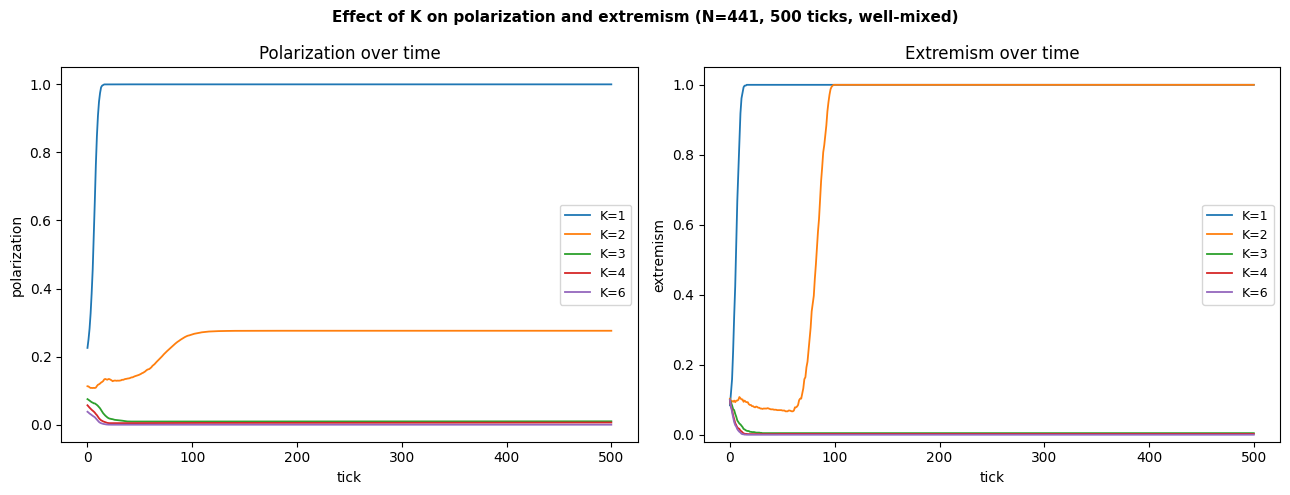

In [8]:
# ── QUICK K SWEEP (single rep per K for visualization) ───────────────────────
# Full batch experiment is in Section 9. This gives a fast visual comparison.

K_values   = [1, 2, 3, 4, 6]    # local: K values to compare
ticks_demo = 500                  # local: enough ticks to see trends

fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle(f"Effect of K on polarization and extremism (N={N}, {ticks_demo} ticks, well-mixed)",
              fontsize=11, fontweight='bold')

for K_val in K_values:
    ops_k, nbr_k = initialize(L, K_val, seed=42)    # local: fresh opinions
    pol_k, ext_k, _ = run_simulation(
        ops_k, nbr_k, K_val,
        n_ticks=ticks_demo, record_every=ticks_demo + 1,   # never snapshot
        spatial_interactions=False, seed=42
    )
    axes2[0].plot(pol_k, lw=1.3, label=f'K={K_val}')
    axes2[1].plot(ext_k, lw=1.3, label=f'K={K_val}')

axes2[0].set_title("Polarization over time")
axes2[0].set_xlabel("tick")
axes2[0].set_ylabel("polarization")
axes2[0].legend(fontsize=9)

axes2[1].set_title("Extremism over time")
axes2[1].set_xlabel("tick")
axes2[1].set_ylabel("extremism")
axes2[1].set_ylim(-0.02, 1.05)
axes2[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## 10. Summary and Key Takeaways

### What this model adds to the chapter

Every model in Chapter 5 built on the previous one. Here is the full progression:

| Model | Opinions per agent | Influence mechanism |
|---|---|---|
| Positive influence (5.2) | 1 | Always positive; Eq. 5.1 |
| Bounded confidence (5.3) | 1 | Positive if gap < d; ignore otherwise |
| Negative influence (5.4) | 1 | Positive if gap < d; negative (push apart) if gap ≥ d |
| **Multiple opinions (5.5)** | **K** | **Weight w = 1 − D determines direction continuously** |

### Key results from this model

**More opinions reduce polarization (well-mixed):** With larger $K$, randomly paired
agents tend to have moderate overall distance $D_{ij}$, pushing $w_{ij}$ toward zero.
The extremizing force weakens. For $K \geq 3$, the population typically converges
toward the center rather than the extremes.

**Spatial structure preserves diversity:** Local interactions slow convergence and
sustain a wider range of opinions, because many agents never encounter a suitable
interaction partner at close geographic range.

**The spatial-to-random switch is dramatic:** After 1,000 ticks of spatial interaction,
diversity is maintained. Switching to random mixing causes rapid collapse into
extremism and polarization — illustrating the potential effect of internet-mediated
long-range communication.

### Variable type reference for this model

| Variable | Type | Role |
|---|---|---|
| `opinions` | Agent variable — shape (N, K) | Each agent's K-dimensional opinion vector |
| `L, N, K` | Global variables | Grid size and dimensionality |
| `spatial_interactions` | Global toggle | Well-mixed vs. neighbors-only |
| `neighbor_map` | Global structure | Precomputed von Neumann neighbors |
| `vec_i, vec_j, w, x_ik, x_jk` | Local variables | Temporary values inside update functions |
| `pol_over_time, ext_over_time` | Output (local to run_simulation) | Recorded metrics |
